In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print(df.head())

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (10000, 10)

Columns:
Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

Data types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [6]:
print("Fraud counts:")
print(df["is_fraud"].value_counts())

print("\nFraud percentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

Fraud counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Fraud percentage:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


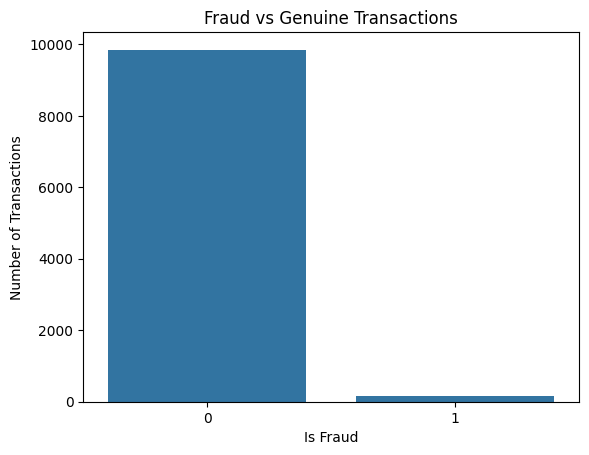

In [7]:
sns.countplot(x="is_fraud", data=df)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Number of Transactions")

plt.show()

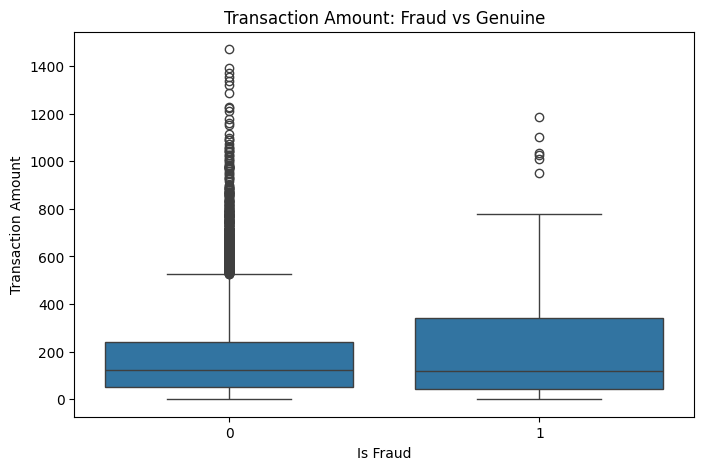

In [8]:
# Fraud transactions by amount

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_fraud", y="amount")

plt.title("Transaction Amount: Fraud vs Genuine")
plt.xlabel("Is Fraud")
plt.ylabel("Transaction Amount")

plt.show()

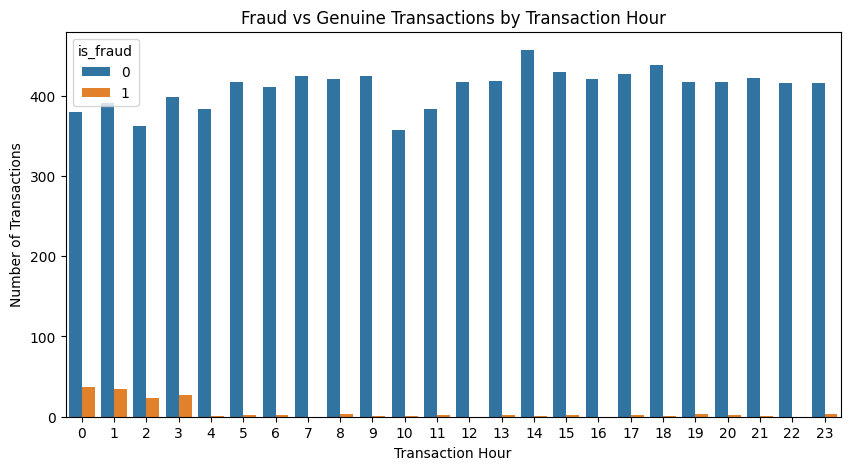

In [9]:
# Fraud transactions by transaction hour

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="transaction_hour",
    hue="is_fraud"
)

plt.title("Fraud vs Genuine Transactions by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")

plt.show()

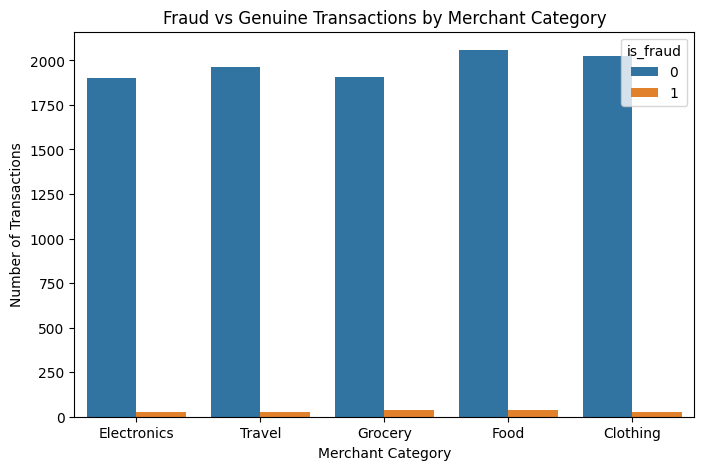

In [10]:
# Fraud transactions by merchant category

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="merchant_category",
    hue="is_fraud"
)

plt.title("Fraud vs Genuine Transactions by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")

plt.show()

In [11]:
# Data Preprocessing

# Check data types
print(df.dtypes)

# Convert categorical column into numbers
df = pd.get_dummies(df, columns=["merchant_category"], drop_first=True)

# Separate features and target
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object
Features shape: (10000, 12)
Target shape: (10000,)


In [12]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 12)
Testing data: (2000, 12)


In [13]:
# Remove transaction_id because it is only an identifier

X_train = X_train.drop("transaction_id", axis=1)
X_test = X_test.drop("transaction_id", axis=1)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (8000, 11)
Testing features: (2000, 11)


In [14]:
print(X_train.columns.tolist())

['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']


In [15]:
# Train Random Forest model

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions completed successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [17]:
# Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9915

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.43      0.60        30

    accuracy                           0.99      2000
   macro avg       1.00      0.72      0.80      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1970    0]
 [  17   13]]


In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [19]:
# Check SMOTE result

print("Original training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original training shape: (8000, 11)
SMOTE training shape: (15758, 11)

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest model trained successfully using SMOTE!")

Random Forest model trained successfully using SMOTE!


In [21]:
# Make predictions using the SMOTE Random Forest model

y_pred_smote = rf_smote.predict(X_test)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred_smote[:10])

Predictions completed successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [22]:
# Evaluate the SMOTE Random Forest model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.45      0.73      0.56        30

    accuracy                           0.98      2000
   macro avg       0.72      0.86      0.77      2000
weighted avg       0.99      0.98      0.98      2000


Confusion Matrix:
[[1943   27]
 [   8   22]]


In [23]:
# Compare Original and SMOTE models

from sklearn.metrics import precision_score, recall_score, f1_score

original_precision = precision_score(y_test, y_pred)
original_recall = recall_score(y_test, y_pred)
original_f1 = f1_score(y_test, y_pred)

smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

print("ORIGINAL RANDOM FOREST")
print("Precision:", original_precision)
print("Recall:", original_recall)
print("F1-score:", original_f1)

print("\nSMOTE RANDOM FOREST")
print("Precision:", smote_precision)
print("Recall:", smote_recall)
print("F1-score:", smote_f1)

ORIGINAL RANDOM FOREST
Precision: 1.0
Recall: 0.43333333333333335
F1-score: 0.6046511627906976

SMOTE RANDOM FOREST
Precision: 0.4489795918367347
Recall: 0.7333333333333333
F1-score: 0.5569620253164557


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1970    0]
 [  17   13]]


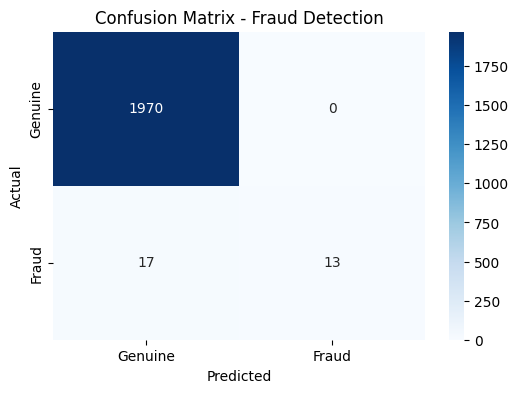

In [25]:
# Visualize Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("Confusion Matrix - Fraud Detection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("SMOTE Confusion Matrix:")
print(cm_smote)

SMOTE Confusion Matrix:
[[1943   27]
 [   8   22]]


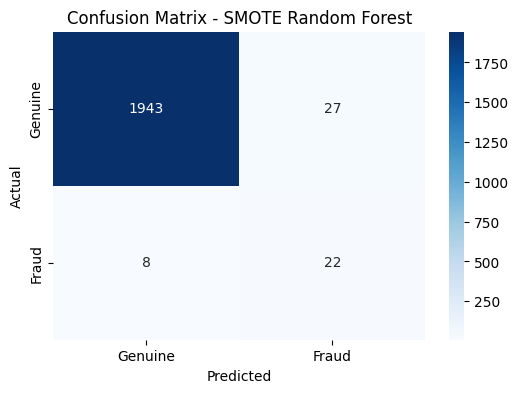

In [27]:
# Confusion Matrix for SMOTE Model

cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.title("Confusion Matrix - SMOTE Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

                          Feature  Importance
4              device_trust_score    0.302605
1                transaction_hour    0.256955
0                          amount    0.089083
5               velocity_last_24h    0.077334
9       merchant_category_Grocery    0.050685
2             foreign_transaction    0.045754
6                  cardholder_age    0.045622
10       merchant_category_Travel    0.042522
8          merchant_category_Food    0.037767
3               location_mismatch    0.031796
7   merchant_category_Electronics    0.019878


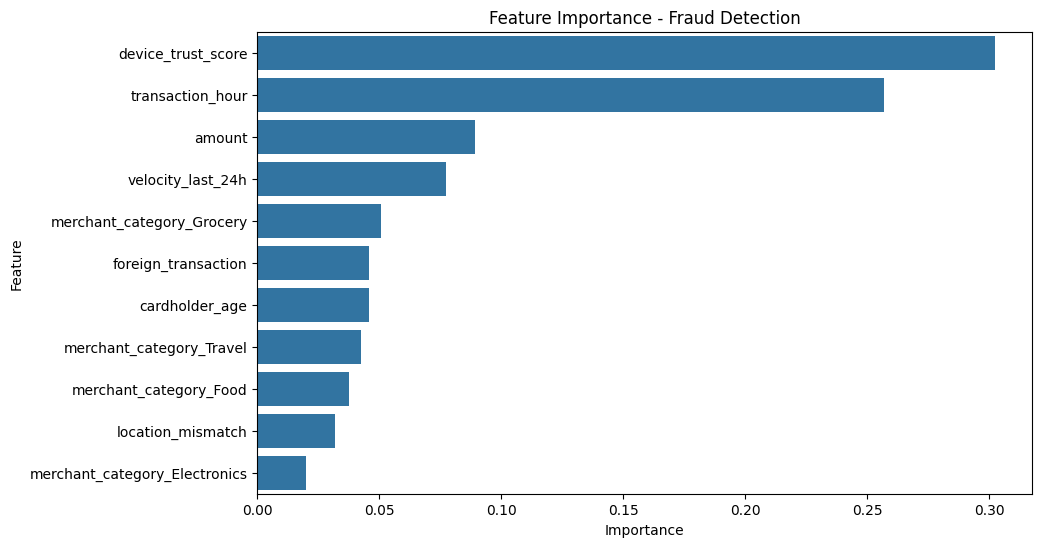

In [33]:
# Feature Importance - SMOTE Random Forest

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_smote.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Fraud Detection")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

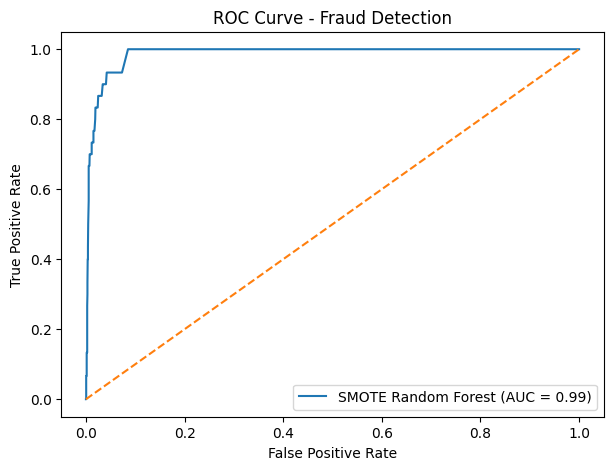

ROC-AUC Score: 0.986844331641286


In [34]:
# ROC Curve - SMOTE Random Forest

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_smote)
auc_score = roc_auc_score(y_test, y_prob_smote)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"SMOTE Random Forest (AUC = {auc_score:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()

plt.show()

print("ROC-AUC Score:", auc_score)

In [28]:
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

print("Probability prediction completed successfully!")

Probability prediction completed successfully!


In [29]:
roc_data = pd.DataFrame({
    "actual": y_test,
    "probability": y_prob_smote
})

roc_data.to_csv(
    "../data/roc_data.csv",
    index=False
)

print("Actual ROC data saved successfully!")

Actual ROC data saved successfully!


In [30]:
import joblib

joblib.dump(
    rf_smote,
    "../models/fraud_detection_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [31]:
loaded_model = joblib.load(
    "../models/fraud_detection_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


ROC-AUC Score: 0.986844331641286


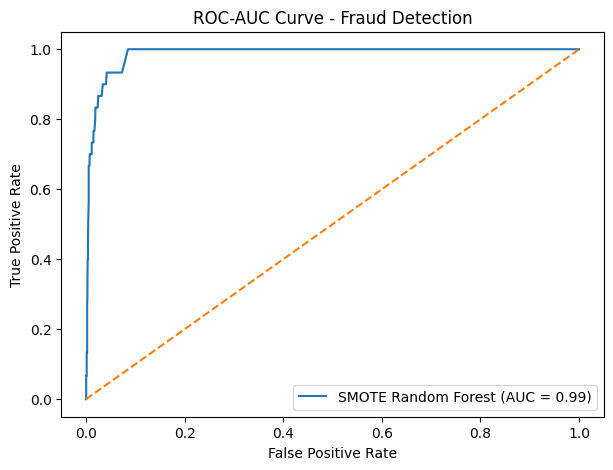

In [32]:
# ROC-AUC Curve for SMOTE Random Forest

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get fraud probabilities
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_smote)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_smote)

print("ROC-AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"SMOTE Random Forest (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve - Fraud Detection")
plt.legend()
plt.show()